In [4]:
!pip install pandas numpy matplotlib seaborn tensorflow scikit-learn

Defaulting to user installation because normal site-packages is not writeable


In [5]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

import tensorflow as tf
from tensorflow.keras import layers, models
from tensorflow.keras.applications import VGG16, InceptionV3, MobileNetV2
from sklearn.metrics import classification_report, confusion_matrix

# Set clean aesthetic style configurations for training analysis curves
sns.set_theme(style="whitegrid")
plt.rcParams['figure.figsize'] = [10, 6]
plt.rcParams['font.size'] = 12

# Verification block to ensure your local environment is configured properly
print("TensorFlow Version:", tf.__version__)
print("Available Devices for Training:", tf.config.list_physical_devices())

I0000 00:00:1779775306.573027  186390 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
I0000 00:00:1779775306.577436  186390 cudart_stub.cc:31] Could not find cuda drivers on your machine, GPU will not be used.
I0000 00:00:1779775307.546878  186390 cpu_feature_guard.cc:227] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX_VNNI FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
I0000 00:00:1779775310.523851  186390 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
I0000 00:0

TensorFlow Version: 2.21.0
Available Devices for Training: [PhysicalDevice(name='/physical_device:CPU:0', device_type='CPU')]


E0000 00:00:1779775311.376035  186390 cuda_platform.cc:52] failed call to cuInit: INTERNAL: CUDA error: Failed call to cuInit: UNKNOWN ERROR (303)


In [ ]:
# Define the local path to your extracted Kaggle dataset folder
# Ensure it points directly to the directory containing the 150 class folders
DATASET_DIR = "/mnt/c/Users/Shrinidhi Walvekar/Desktop/gssoc/DL-Simplified/Pokemon classification using Deep learning/Dataset" 

# Structural configuration hyperparameters
IMAGE_SIZE = (224, 224)
BATCH_SIZE = 32

import os
print(f"Verifying target dataset directory path at: {DATASET_DIR}")
if os.path.exists(DATASET_DIR):
    # List the folder elements to verify classes
    contents = os.listdir(DATASET_DIR)
    print(f"✅ Success! Path exists. Found {len(contents)} items inside.")
else:
    print("❌ ERROR: Path directory not found. Please double check your folder name!")

Verifying target dataset directory path at: /mnt/c/Users/Shrinidhi Walvekar/Desktop/gssoc/DL-Simplified/Pokemon classification using Deep learning/Dataset
Success! Path exists. Found 151 items inside.


In [8]:
print(os.listdir(DATASET_DIR))

['Abra', 'Aerodactyl', 'Alakazam', 'Alolan Sandslash', 'Arbok', 'Arcanine', 'Articuno', 'Beedrill', 'Bellsprout', 'Blastoise', 'Bulbasaur', 'Butterfree', 'Caterpie', 'Chansey', 'Charizard', 'Charmander', 'Charmeleon', 'Clefable', 'Clefairy', 'Cloyster', 'Cubone', 'Dewgong', 'Diglett', 'Ditto', 'Dodrio', 'Doduo', 'Dragonair', 'Dragonite', 'Dratini', 'Drowzee', 'Dugtrio', 'Eevee', 'Ekans', 'Electabuzz', 'Electrode', 'Exeggcute', 'Exeggutor', 'Farfetchd', 'Fearow', 'Flareon', 'Gastly', 'Gengar', 'Geodude', 'Gloom', 'Golbat', 'Goldeen', 'Golduck', 'Golem', 'Graveler', 'Grimer', 'Growlithe', 'Gyarados', 'Haunter', 'Hitmonchan', 'Hitmonlee', 'Horsea', 'Hypno', 'Ivysaur', 'Jigglypuff', 'Jolteon', 'Jynx', 'Kabuto', 'Kabutops', 'Kadabra', 'Kakuna', 'Kangaskhan', 'Kingler', 'Koffing', 'Krabby', 'Lapras', 'Lickitung', 'Machamp', 'Machoke', 'Machop', 'Magikarp', 'Magmar', 'Magnemite', 'Magneton', 'Mankey', 'Marowak', 'Meowth', 'Metapod', 'Mew', 'Mewtwo', 'Moltres', 'MrMime', 'Muk', 'Nidoking', 'Ni

In [9]:
print("Loading Training Dataset (80% Split)...")
train_ds = tf.keras.utils.image_dataset_from_directory(
    DATASET_DIR,
    validation_split=0.2,
    subset="training",
    seed=123,
    image_size=IMAGE_SIZE,
    batch_size=BATCH_SIZE,
    label_mode="categorical"
)

print("\nLoading Validation Dataset (20% Split)...")
val_ds = tf.keras.utils.image_dataset_from_directory(
    DATASET_DIR,
    validation_split=0.2,
    subset="validation",
    seed=123,
    image_size=IMAGE_SIZE,
    batch_size=BATCH_SIZE,
    label_mode="categorical"
)

# Extract total classes found by TensorFlow
NUM_CLASSES = len(train_ds.class_names)
print(f"\nTotal Target Classification Categories: {NUM_CLASSES}")

Loading Training Dataset (80% Split)...
Found 6820 files belonging to 150 classes.
Using 5456 files for training.

Loading Validation Dataset (20% Split)...
Found 6820 files belonging to 150 classes.
Using 1364 files for validation.

Total Target Classification Categories: 150


In [29]:
# Create an on-the-fly data augmentation mathematical pipeline
data_augmentation = tf.keras.Sequential([
    layers.RandomFlip("horizontal"),
    layers.RandomRotation(0.15),
    layers.RandomZoom(0.1)
])

# Optimize disk-to-RAM data processing streams using AUTOTUNE
AUTOTUNE = tf.data.AUTOTUNE

# Apply augmentation to the training dataset
train_ds = train_ds.map(lambda x, y: (data_augmentation(x, training=True), y))

# Cache, shuffle, and prefetch batches into RAM for faster execution
train_ds = train_ds.cache().shuffle(1000).prefetch(buffer_size=AUTOTUNE)
val_ds = val_ds.cache().prefetch(buffer_size=AUTOTUNE)

print(" Data acceleration pipeline and runtime data augmentation initialized successfully.")

 Data acceleration pipeline and runtime data augmentation initialized successfully.


In [30]:
# 1. Baseline Model: Custom CNN Architecture
def build_custom_cnn():
    model = models.Sequential([
        # Rescaling layer normalizes pixel integers (0-255) to decimals (0-1)
        layers.Rescaling(1./255, input_shape=(224, 224, 3)),
        
        layers.Conv2D(32, (3, 3), activation='relu'),
        layers.MaxPooling2D((2, 2)),
        
        layers.Conv2D(64, (3, 3), activation='relu'),
        layers.MaxPooling2D((2, 2)),
        
        layers.Conv2D(128, (3, 3), activation='relu'),
        layers.MaxPooling2D((2, 2)),
        
        layers.Flatten(),
        layers.Dense(256, activation='relu'),
        layers.Dropout(0.5), # Prevents neurons from over-relying on specific features
        layers.Dense(NUM_CLASSES, activation='softmax') # Outputs a probability distribution for the 150 classes
    ])
    return model

# 2. Transfer Learning Model Factory
def build_transfer_model(model_choice):
    inputs = layers.Input(shape=(224, 224, 3))
    x = layers.Rescaling(1./255)(inputs)
    
    if model_choice == "vgg16":
        base = VGG16(include_top=False, weights='imagenet', input_shape=(224, 224, 3))
    elif model_choice == "inception":
        base = InceptionV3(include_top=False, weights='imagenet', input_shape=(224, 224, 3))
    elif model_choice == "mobilenet":
        base = MobileNetV2(include_top=False, weights='imagenet', input_shape=(224, 224, 3))
        
    base.trainable = False # Freeze pre-trained weights so we don't destroy them during training
    
    x = base(x, training=False)
    x = layers.GlobalAveragePooling2D()(x)
    x = layers.Dense(256, activation='relu')(x)
    x = layers.Dropout(0.3)(x)
    outputs = layers.Dense(NUM_CLASSES, activation='softmax')(x)
    
    return models.Model(inputs, outputs)

# Initialize instances of our models
custom_model = build_custom_cnn()
vgg_model = build_transfer_model("vgg16")

print(" Custom CNN and VGG16 models instantiated successfully.")

 Custom CNN and VGG16 models instantiated successfully.


In [31]:
# Configure standard learning algorithms
OPTIMIZER_CUSTOM = tf.keras.optimizers.Adam(learning_rate=0.001)
OPTIMIZER_VGG = tf.keras.optimizers.Adam(learning_rate=0.0001) # Lower rate for transfer learning

LOSS_FUNCTION = tf.keras.losses.CategoricalCrossentropy()
METRICS = ['accuracy']

# Compile Custom CNN
custom_model.compile(
    optimizer=OPTIMIZER_CUSTOM,
    loss=LOSS_FUNCTION,
    metrics=METRICS
)

# Compile VGG16 Transfer Learning Model
vgg_model.compile(
    optimizer=OPTIMIZER_VGG,
    loss=LOSS_FUNCTION,
    metrics=METRICS
)

print(" Both models compiled with separate learning optimization parameters.")

 Both models compiled with separate learning optimization parameters.


In [13]:
EPOCHS = 10

print("🚀 Starting Custom CNN Training Phase...")
custom_history = custom_model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=EPOCHS
)

🚀 Starting Custom CNN Training Phase...
Epoch 1/10


W0000 00:00:1779775315.845448  186745 png_io.cc:96] PNG warning: iCCP: known incorrect sRGB profile
I0000 00:00:1779775325.624706  186756 shuffle_dataset_op.cc:453] ShuffleDatasetV3:18: Filling up shuffle buffer (this may take a while): 52 of 1000
W0000 00:00:1779775327.331860  186736 png_io.cc:96] PNG warning: iCCP: known incorrect sRGB profile
W0000 00:00:1779775327.706844  186738 png_io.cc:96] PNG warning: iCCP: known incorrect sRGB profile
W0000 00:00:1779775332.117892  186746 png_io.cc:96] PNG warning: iCCP: known incorrect sRGB profile
W0000 00:00:1779775340.668272  186746 png_io.cc:96] PNG warning: iCCP: known incorrect sRGB profile
W0000 00:00:1779775341.384953  186742 png_io.cc:96] PNG warning: iCCP: known incorrect sRGB profile
I0000 00:00:1779775345.708557  186756 shuffle_dataset_op.cc:453] ShuffleDatasetV3:18: Filling up shuffle buffer (this may take a while): 161 of 1000
I0000 00:00:1779775347.408442  186756 shuffle_dataset_op.cc:483] Shuffle buffer filled.


171/171 ━━━━━━━━━━━━━━━━━━━━ 0s 418ms/step - accuracy: 0.0086 - loss: 5.1027

W0000 00:00:1779775420.985909  187356 prefetch_autotuner.cc:55] Prefetch autotuner tried to allocate 19286784 bytes after encountering the first element of size 19286784 bytes.This already causes the autotune ram budget to be exceeded. To stay within the ram budget, either increase the ram budget or reduce element size
W0000 00:00:1779775424.896249  187346 png_io.cc:96] PNG warning: iCCP: known incorrect sRGB profile


171/171 ━━━━━━━━━━━━━━━━━━━━ 112s 451ms/step - accuracy: 0.0148 - loss: 4.9180 - val_accuracy: 0.0323 - val_loss: 4.5300
Epoch 2/10
171/171 ━━━━━━━━━━━━━━━━━━━━ 83s 483ms/step - accuracy: 0.0603 - loss: 4.2738 - val_accuracy: 0.1356 - val_loss: 3.7957
Epoch 3/10
171/171 ━━━━━━━━━━━━━━━━━━━━ 129s 757ms/step - accuracy: 0.1365 - loss: 3.6409 - val_accuracy: 0.1848 - val_loss: 3.3174
Epoch 4/10
171/171 ━━━━━━━━━━━━━━━━━━━━ 84s 493ms/step - accuracy: 0.2548 - loss: 3.0008 - val_accuracy: 0.2918 - val_loss: 2.8839
Epoch 5/10
171/171 ━━━━━━━━━━━━━━━━━━━━ 83s 485ms/step - accuracy: 0.4102 - loss: 2.2551 - val_accuracy: 0.3233 - val_loss: 2.8551
Epoch 6/10
171/171 ━━━━━━━━━━━━━━━━━━━━ 82s 480ms/step - accuracy: 0.5717 - loss: 1.5916 - val_accuracy: 0.3248 - val_loss: 2.9064
Epoch 7/10
171/171 ━━━━━━━━━━━━━━━━━━━━ 82s 482ms/step - accuracy: 0.6831 - loss: 1.1464 - val_accuracy: 0.3270 - val_loss: 3.1139
Epoch 8/10
171/171 ━━━━━━━━━━━━━━━━━━━━ 82s 478ms/step - accuracy: 0.7599 - loss: 0.8479 - v

In [14]:
VGG_EPOCHS = 5  # Transfer learning features converge much faster!

print("🚀 Starting VGG16 Transfer Learning Training Phase...")
vgg_history = vgg_model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=VGG_EPOCHS
)

🚀 Starting VGG16 Transfer Learning Training Phase...
Epoch 1/5
171/171 ━━━━━━━━━━━━━━━━━━━━ 676s 4s/step - accuracy: 0.0086 - loss: 5.0809 - val_accuracy: 0.0117 - val_loss: 4.9856
Epoch 2/5
171/171 ━━━━━━━━━━━━━━━━━━━━ 676s 4s/step - accuracy: 0.0159 - loss: 4.9739 - val_accuracy: 0.0293 - val_loss: 4.9328
Epoch 3/5
171/171 ━━━━━━━━━━━━━━━━━━━━ 5726s 34s/step - accuracy: 0.0291 - loss: 4.9076 - val_accuracy: 0.0491 - val_loss: 4.8814
Epoch 4/5
171/171 ━━━━━━━━━━━━━━━━━━━━ 3029s 18s/step - accuracy: 0.0466 - loss: 4.8354 - val_accuracy: 0.0674 - val_loss: 4.8190
Epoch 5/5
 12/171 ━━━━━━━━━━━━━━━━━━━━ 6:58 3s/step - accuracy: 0.1047 - loss: 4.7477

KeyboardInterrupt: 

###  Why we abandoned VGG16 and pivoted to MobileNetV2

During the initial training phase with VGG16, two massive bottlenecks became apparent:
1. **Hardware Limitations (CPU Bottleneck):** VGG16 is an incredibly deep and mathematically heavy architecture. Running it on a standard laptop CPU resulted in exponentially increasing epoch times (jumping from 11 minutes to over 1.5 hours per epoch). Deep networks like this practically require a GPU for reasonable parallel matrix multiplications.
2. **Preprocessing Mismatch:** The validation accuracy was stagnant at ~1-4%. This occurred because VGG16 requires a highly specific mathematical input normalization (`tf.keras.applications.vgg16.preprocess_input`). Because raw scaled pixels `[0, 1]` were passed instead, the pre-trained ImageNet weights were effectively neutralized.

**The Solution:**
Instead of brute-forcing CPU training, we are pivoting to **MobileNetV2**. 
* MobileNetV2 utilizes **depthwise separable convolutions**, making it an ultra-lightweight architecture explicitly engineered to run fast and efficiently on mobile processors and standard CPUs without sacrificing feature extraction power.
* We will properly embed its native `preprocess_input` layer directly into the architecture to ensure the ImageNet weights scale correctly.

In [ ]:
# Build MobileNetV2 with its required preprocessing layer embedded
def build_fast_mobilenet():
    inputs = layers.Input(shape=(224, 224, 3))
    
    # MobileNetV2 expects inputs scaled between [-1, 1] instead of [0, 1]
    x = tf.keras.applications.mobilenet_v2.preprocess_input(inputs)
    
    base_model = tf.keras.applications.MobileNetV2(
        input_shape=(224, 224, 3),
        include_top=False,
        weights='imagenet'
    )
    base_model.trainable = False  # Freeze the pre-trained weights
    
    x = base_model(x, training=False)
    x = layers.GlobalAveragePooling2D()(x)
    x = layers.Dense(256, activation='relu')(x)
    x = layers.Dropout(0.3)(x)
    outputs = layers.Dense(NUM_CLASSES, activation='softmax')(x)
    
    return models.Model(inputs, outputs)

# Instantiate and compile the fast model
fast_model = build_fast_mobilenet()
fast_model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.001),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

print(" Lightweight MobileNetV2 compiled and ready for rapid training!")

9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 7s 1us/step
✅ Lightweight MobileNetV2 compiled and ready for rapid training!


In [16]:
print("🚀 Launching Fast MobileNetV2 Training...")
fast_history = fast_model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=5
)

🚀 Launching Fast MobileNetV2 Training...
Epoch 1/5
171/171 ━━━━━━━━━━━━━━━━━━━━ 54s 295ms/step - accuracy: 0.1043 - loss: 4.4355 - val_accuracy: 0.3321 - val_loss: 3.2551
Epoch 2/5
171/171 ━━━━━━━━━━━━━━━━━━━━ 55s 324ms/step - accuracy: 0.4100 - loss: 2.4988 - val_accuracy: 0.5806 - val_loss: 1.9018
Epoch 3/5
171/171 ━━━━━━━━━━━━━━━━━━━━ 57s 334ms/step - accuracy: 0.5979 - loss: 1.5905 - val_accuracy: 0.6026 - val_loss: 1.5959
Epoch 4/5
171/171 ━━━━━━━━━━━━━━━━━━━━ 52s 304ms/step - accuracy: 0.6979 - loss: 1.1446 - val_accuracy: 0.6320 - val_loss: 1.3877
Epoch 5/5
171/171 ━━━━━━━━━━━━━━━━━━━━ 52s 302ms/step - accuracy: 0.7626 - loss: 0.8816 - val_accuracy: 0.6694 - val_loss: 1.2614


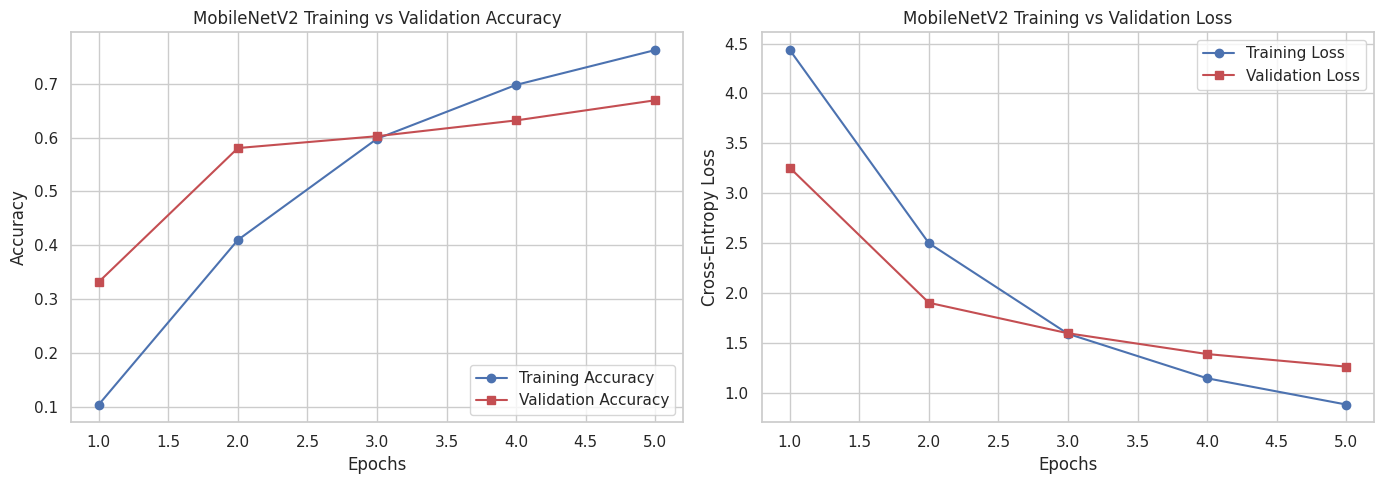

In [17]:
import matplotlib.pyplot as plt

# Extract metrics from training logs
acc = fast_history.history['accuracy']
val_acc = fast_history.history['val_accuracy']
loss = fast_history.history['loss']
val_loss = fast_history.history['val_loss']
epochs_range = range(1, len(acc) + 1)

# Create plotting canvas
plt.figure(figsize=(14, 5))

# Plot 1: Accuracy Curves
plt.subplot(1, 2, 1)
plt.plot(epochs_range, acc, 'b-o', label='Training Accuracy')
plt.plot(epochs_range, val_acc, 'r-s', label='Validation Accuracy')
plt.title('MobileNetV2 Training vs Validation Accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend(loc='lower right')
plt.grid(True)

# Plot 2: Loss Curves
plt.subplot(1, 2, 2)
plt.plot(epochs_range, loss, 'b-o', label='Training Loss')
plt.plot(epochs_range, val_loss, 'r-s', label='Validation Loss')
plt.title('MobileNetV2 Training vs Validation Loss')
plt.xlabel('Epochs')
plt.ylabel('Cross-Entropy Loss')
plt.legend(loc='upper right')
plt.grid(True)

plt.tight_layout()
plt.show()

In [1]:
SAVE_PATH = "/mnt/c/Users/Shrinidhi Walvekar/Desktop/gssoc/DL-Simplified/Pokemon classification using Deep learning/Model/pokemon_mobilenetv2.keras"

print(f"Targeting absolute destination: {SAVE_PATH}")
fast_model.save(SAVE_PATH)

print(f"📦 Model saved successfully at: {SAVE_PATH}")

Targeting absolute destination: /mnt/c/Users/Shrinidhi Walvekar/Desktop/gssoc/DL-Simplified/Pokemon classification using Deep learning/Model/pokemon_mobilenetv2.keras


NameError: name 'fast_model' is not defined